# 03 · Route split and CAN target statistics

No random frame split. Splits are route-level and are made separately within each comma2k19 vehicle.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import subprocess
import sys

# ============================================================
# Repository
# ============================================================
REPO = Path("/content/Blackbox-Detection")
REPO_URL = "https://github.com/sangchun1/Blackbox-Detection.git"
BRANCH = "stage3-sangchun"

if not REPO.exists():
    subprocess.run(
        [
            "git", "clone",
            "--branch", BRANCH,
            "--single-branch",
            REPO_URL,
            str(REPO),
        ],
        check=True,
    )
else:
    subprocess.run(
        ["git", "-C", str(REPO), "fetch", "origin", BRANCH],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(REPO), "checkout", BRANCH],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(REPO), "pull", "--ff-only", "origin", BRANCH],
        check=True,
    )

# ============================================================
# Paths
# ============================================================
DRIVE_ROOT = Path("/content/drive/MyDrive/Blackbox-Detection")
DATA_ROOT = DRIVE_ROOT / "DATASET"

COMMA_ROOT = DATA_ROOT / "comma2k19"
RAW_ROOT = COMMA_ROOT / "raw"
PROCESSED_ROOT = COMMA_ROOT / "processed" / "v1"

MANIFEST_ROOT = DRIVE_ROOT / "manifests" / "stage3" / "v1"
OUTPUT_ROOT = DRIVE_ROOT / "outputs" / "stage3"
PRETRAINED_ROOT = DRIVE_ROOT / "pretrained"

for p in [PROCESSED_ROOT, MANIFEST_ROOT, OUTPUT_ROOT, PRETRAINED_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

# ============================================================
# Install project from the existing pyproject.toml
# --no-deps keeps Colab's/DACON's binary stack intact.
# ============================================================
subprocess.run(
    [
        sys.executable,
        "-m", "pip", "install",
        "-q", "--no-deps", "-e", str(REPO),
    ],
    check=True,
)

if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

commit = subprocess.check_output(
    ["git", "-C", str(REPO), "rev-parse", "--short", "HEAD"],
    text=True,
).strip()

print("Repository     :", REPO)
print("Branch         :", BRANCH)
print("Commit         :", commit)
print("RAW_ROOT       :", RAW_ROOT)
print("PROCESSED_ROOT :", PROCESSED_ROOT)

Mounted at /content/drive
Repository     : /content/Blackbox-Detection
Branch         : stage3-sangchun
Commit         : 9de6978
RAW_ROOT       : /content/drive/MyDrive/Blackbox-Detection/DATASET/comma2k19/raw
PROCESSED_ROOT : /content/drive/MyDrive/Blackbox-Detection/DATASET/comma2k19/processed/v1


In [2]:
import json
import numpy as np
import pandas as pd

from blackbox_detection.stage3.manifest import (
    build_segment_manifest,
    split_routes,
    compute_target_stats,
    save_stats,
)

# ============================================================
# Build raw manifest
# ============================================================
manifest_raw = build_segment_manifest(PROCESSED_ROOT)
assert len(manifest_raw), "Processed manifest is empty."

print("raw segments:", len(manifest_raw))

# ============================================================
# Temporal-quality filter
#
# Stage 3 is a dense dynamics task.
# Segments whose timestamp-derived sampling rate deviates too
# far from 10 Hz can distort acceleration / steering dynamics.
# Keep the processed files on Drive, but exclude them from
# training / validation manifests.
# ============================================================
manifest_raw["effective_hz"] = (
    (manifest_raw["num_frames"] - 1)
    / manifest_raw["duration_s"].replace(0, np.nan)
)

keep = manifest_raw["effective_hz"].between(9.5, 10.5)

excluded = (
    manifest_raw.loc[~keep]
    .copy()
    .sort_values(["vehicle_id", "route_id", "segment_id"])
    .reset_index(drop=True)
)

manifest = (
    manifest_raw.loc[keep]
    .copy()
    .reset_index(drop=True)
)

print("kept segments    :", len(manifest))
print("excluded segments:", len(excluded))

assert len(manifest) > 0
assert manifest["effective_hz"].between(9.5, 10.5).all()

# Audit trail
excluded.to_csv(
    MANIFEST_ROOT / "comma_excluded_temporal.csv",
    index=False,
)

# ============================================================
# Route-level split
# ============================================================
train, val = split_routes(
    manifest,
    val_fraction=0.15,
    seed=20260918,
)

train.to_csv(
    MANIFEST_ROOT / "comma_train.csv",
    index=False,
)

val.to_csv(
    MANIFEST_ROOT / "comma_val_id.csv",
    index=False,
)

manifest.to_csv(
    MANIFEST_ROOT / "comma_all.csv",
    index=False,
)

print("\nall  :", len(manifest), "segments")
print(
    "train:",
    len(train),
    "segments / routes",
    train.route_id.nunique(),
)
print(
    "val  :",
    len(val),
    "segments / routes",
    val.route_id.nunique(),
)

assert set(train.route_id).isdisjoint(set(val.route_id))

print("\nvehicle distribution")
display(
    manifest.groupby("vehicle_id")
    .size()
    .rename("all")
)

display(
    train.groupby("vehicle_id")
    .size()
    .rename("train")
)

display(
    val.groupby("vehicle_id")
    .size()
    .rename("val")
)

print("\nexcluded temporal-quality segments")
display(
    excluded[
        [
            "vehicle_id",
            "route_id",
            "segment_id",
            "num_frames",
            "duration_s",
            "effective_hz",
        ]
    ]
)

raw segments: 2035
kept segments    : 1997
excluded segments: 38

all  : 1997 segments
train: 1649 segments / routes 152
val  : 348 segments / routes 26

vehicle distribution


,all
vehicle_id,
99c94dc769b5d96e,1615
b0c9d2329ad1606b,382


,train
vehicle_id,
99c94dc769b5d96e,1333
b0c9d2329ad1606b,316


,val
vehicle_id,
99c94dc769b5d96e,282
b0c9d2329ad1606b,66



excluded temporal-quality segments


,vehicle_id,route_id,segment_id,num_frames,duration_s,effective_hz
0,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,10,525,59.949139,8.740743
1,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,11,530,59.899160,8.831509
2,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,12,539,59.949162,8.974271
3,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,13,523,59.849184,8.721923
4,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,14,539,59.949159,8.974271
5,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,15,551,59.949158,9.174441
6,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,16,530,59.899141,8.831512
7,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,17,543,59.899188,9.048537
8,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,18,557,59.899151,9.282268
9,99c94dc769b5d96e,99c94dc769b5d96e|2018-10-12--20-13-54,19,549,59.899183,9.148706


In [3]:
stats = compute_target_stats(train, PROCESSED_ROOT)
save_stats(stats, MANIFEST_ROOT / "target_stats.json")
print(json.dumps(stats, indent=2))

{
  "speed_mps": {
    "mean": 22.244219252137764,
    "std": 11.211407260985206,
    "min": -0.15261083841323853,
    "max": 46.522254943847656,
    "n": 984742
  },
  "accel_from_speed_mps2": {
    "mean": 0.0008632693445153883,
    "std": 0.4973502921788985,
    "min": -5.13859224319458,
    "max": 4.528941631317139,
    "n": 983064
  },
  "steering_deg": {
    "mean": -0.024051861255939538,
    "std": 19.589864250399714,
    "min": -482.1000061035156,
    "max": 394.29998779296875,
    "n": 984805
  },
  "yaw_rate_rps": {
    "mean": -0.0072673009771956265,
    "std": 0.03709767249492849,
    "min": -0.9981051087379456,
    "max": 0.7496059536933899,
    "n": 984801
  }
}


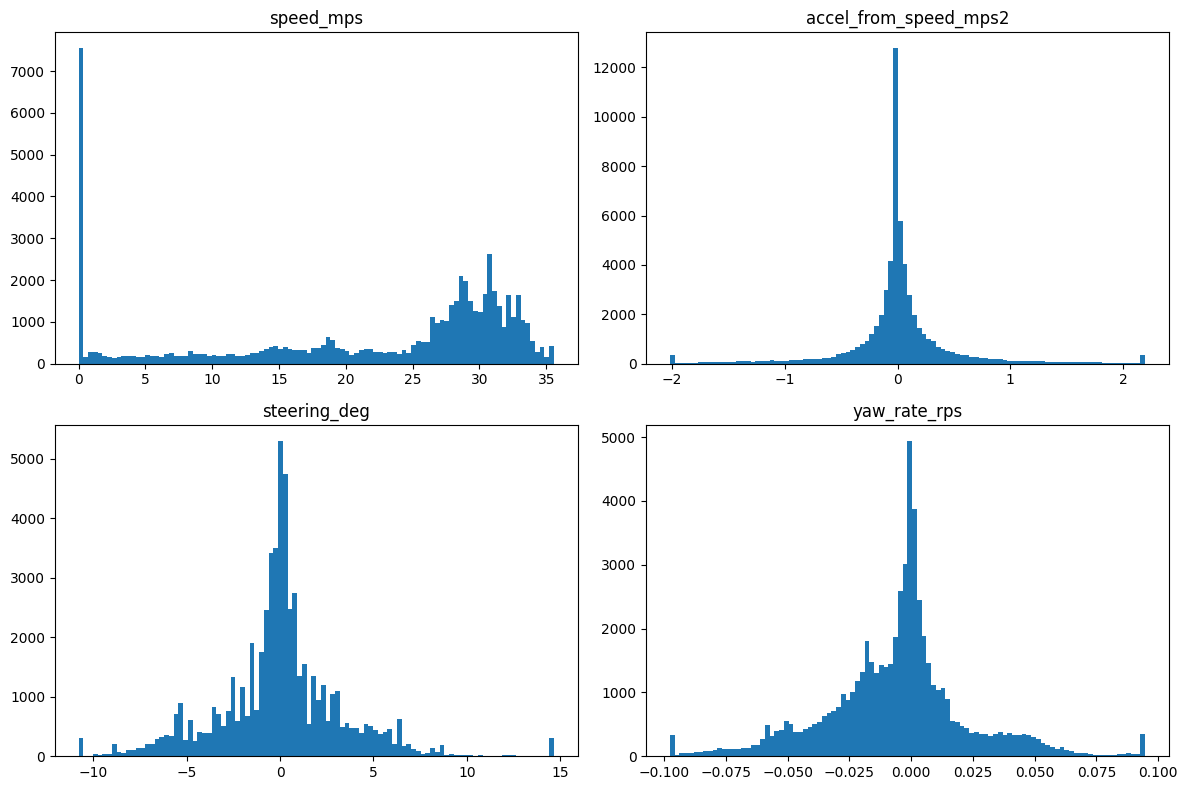

In [4]:
from blackbox_detection.stage3.schema import read_frame_table
import numpy as np
import matplotlib.pyplot as plt

sample_rows = train.sample(min(100, len(train)), random_state=20260918)

frames = pd.concat(
    [
        read_frame_table(PROCESSED_ROOT / r.metadata_relpath)
        for r in sample_rows.itertuples()
    ],
    ignore_index=True,
)

cols = [
    "speed_mps",
    "accel_from_speed_mps2",
    "steering_deg",
    "yaw_rate_rps",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, cols):
    x = frames[col].replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = x.quantile([0.005, 0.995])
    ax.hist(x.clip(lo, hi), bins=100)
    ax.set_title(col)

plt.tight_layout()
plt.show()